# 2. Statistisk Analys
Deskriptiv statistik, fördelningar och normalitetstest för WHR26-variablerna.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from pathlib import Path

_here = Path().resolve()
DATA_DIR = _here / 'data' if (_here / 'data').exists() else _here.parent / 'data'

df = pd.read_csv(DATA_DIR / 'cleaned_data.csv')

FEATURE_COLS = ['gdp', 'social_support', 'health', 'freedom', 'generosity', 'corruption', 'dystopia_residual']
TARGET = 'happiness_score'

In [2]:
df[[TARGET] + FEATURE_COLS].describe().round(3)

,happiness_score,gdp,social_support,health,freedom,generosity,corruption,dystopia_residual
count,1013.000,1013.000,1013.000,1013.000,1013.000,1013.000,1013.000,1013.000
mean,5.553,1.266,1.095,0.553,0.609,0.148,0.145,1.737
std,1.127,0.465,0.358,0.230,0.212,0.084,0.119,0.657
min,1.364,0.000,0.000,0.000,0.000,0.000,0.000,-0.295
25%,4.729,0.944,0.865,0.389,0.471,0.089,0.063,1.305
50%,5.714,1.306,1.135,0.560,0.602,0.134,0.113,1.765
75%,6.387,1.636,1.379,0.712,0.735,0.196,0.181,2.178
max,7.842,2.209,1.840,1.238,1.147,0.570,0.587,3.482


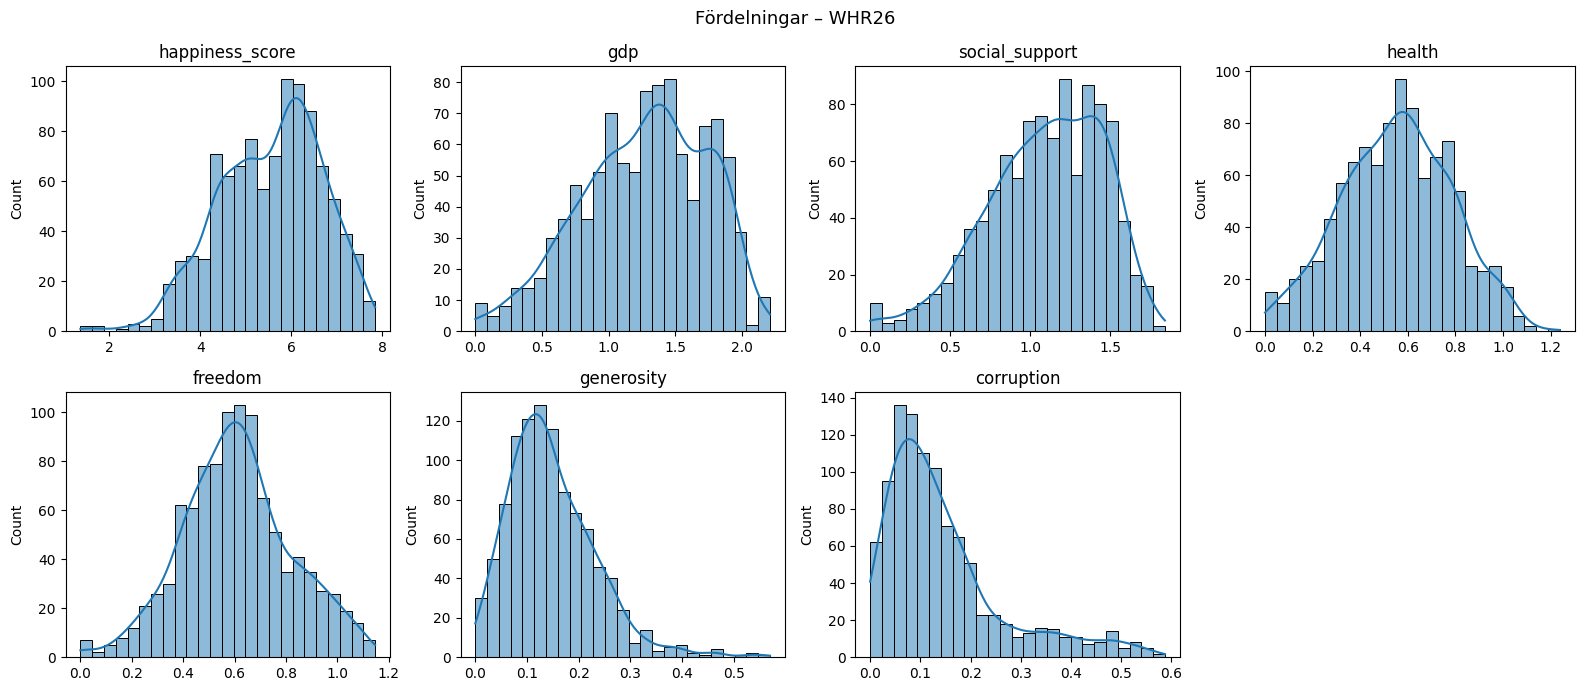

In [3]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for ax, col in zip(axes.flat, [TARGET] + FEATURE_COLS):
    sns.histplot(df[col], kde=True, ax=ax, bins=25)
    ax.set_title(col)
    ax.set_xlabel('')
axes.flat[-1].set_visible(False)
plt.suptitle('Fördelningar – WHR26', fontsize=13)
plt.tight_layout()
plt.savefig(DATA_DIR / 'distributions.png', dpi=150)
plt.show()

In [4]:
# Normalitetstest (Shapiro-Wilk) på senaste årets data
latest = df[df['Year'] == df['Year'].max()]
print(f'Shapiro-Wilk (år {latest["Year"].iloc[0]}):')
for col in [TARGET] + FEATURE_COLS:
    stat, p = stats.shapiro(latest[col].dropna())
    normal = 'normal' if p > 0.05 else 'INTE normal'
    print(f'  {col:<35} W={stat:.4f}  p={p:.4f}  -> {normal}')

Shapiro-Wilk (år 2025):
  happiness_score                     W=0.9527  p=0.0001  -> INTE normal
  gdp                                 W=0.9491  p=0.0000  -> INTE normal
  social_support                      W=0.9169  p=0.0000  -> INTE normal
  health                              W=0.9786  p=0.0230  -> INTE normal
  freedom                             W=0.9009  p=0.0000  -> INTE normal
  generosity                          W=0.9700  p=0.0029  -> INTE normal
  corruption                          W=0.8676  p=0.0000  -> INTE normal
  dystopia_residual                   W=0.9863  p=0.1606  -> normal


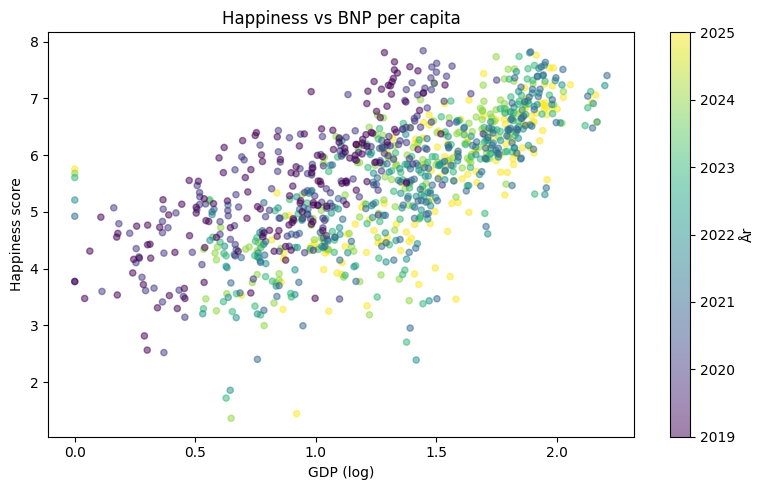

In [5]:
plt.figure(figsize=(8, 5))
scatter = plt.scatter(df['gdp'], df[TARGET], c=df['Year'], cmap='viridis', alpha=0.5, s=20)
plt.colorbar(scatter, label='År')
plt.xlabel('GDP (log)')
plt.ylabel('Happiness score')
plt.title('Happiness vs BNP per capita')
plt.tight_layout()
plt.savefig(DATA_DIR / 'happiness_vs_gdp.png', dpi=150)
plt.show()

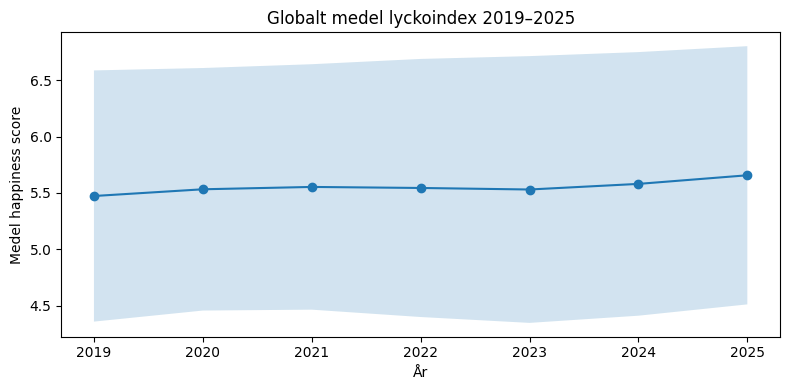

In [6]:
yearly = df.groupby('Year')[TARGET].agg(['mean', 'std']).reset_index()
plt.figure(figsize=(8, 4))
plt.plot(yearly['Year'], yearly['mean'], marker='o')
plt.fill_between(yearly['Year'], yearly['mean'] - yearly['std'], yearly['mean'] + yearly['std'], alpha=0.2)
plt.xlabel('År')
plt.ylabel('Medel happiness score')
plt.title('Globalt medel lyckoindex 2019–2025')
plt.tight_layout()
plt.savefig(DATA_DIR / 'yearly_trend.png', dpi=150)
plt.show()